## This notebook presents the result analysis and visualization for submission NCOMMS-26-018997-T

**Title:** *Impacts and Benefits of Electrified Space Heating on Renewable-Based Power Systems*

This notebook contains the analysis of simulation results and the corresponding visualizations prepared for the above submission.

Supplementary Figure 5: Comparison on monthly import and expert with HP flexibility in Switzerland in 2050
under various HP deployment scenarios.


**Contact:** Yi Guo  
**Email:** yi.guo@bit.edu.cn

### Supplementary Figure 5: Monthly trading comparison in the case with and without HP flexible operation

This section refines the monthly trading comparison between the scenarios with and without HP flexible operation.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_29936\535757387.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dr = pd.date_range(start=f'{year}-01-01 00:00:00', periods=8760, freq='H')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_29936\535757387.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dr = pd.date_range(start=f'{year}-01-01 00:00:00', periods=8760, freq='H')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_29936\535757387.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dr = pd.date_range(start=f'{year}-01-01 00:00:00', periods=8760, freq='H')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_29936\535757387.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dr = pd.date_range(start=f'{year}-01-01 00:00:00', periods=8760, freq='H')


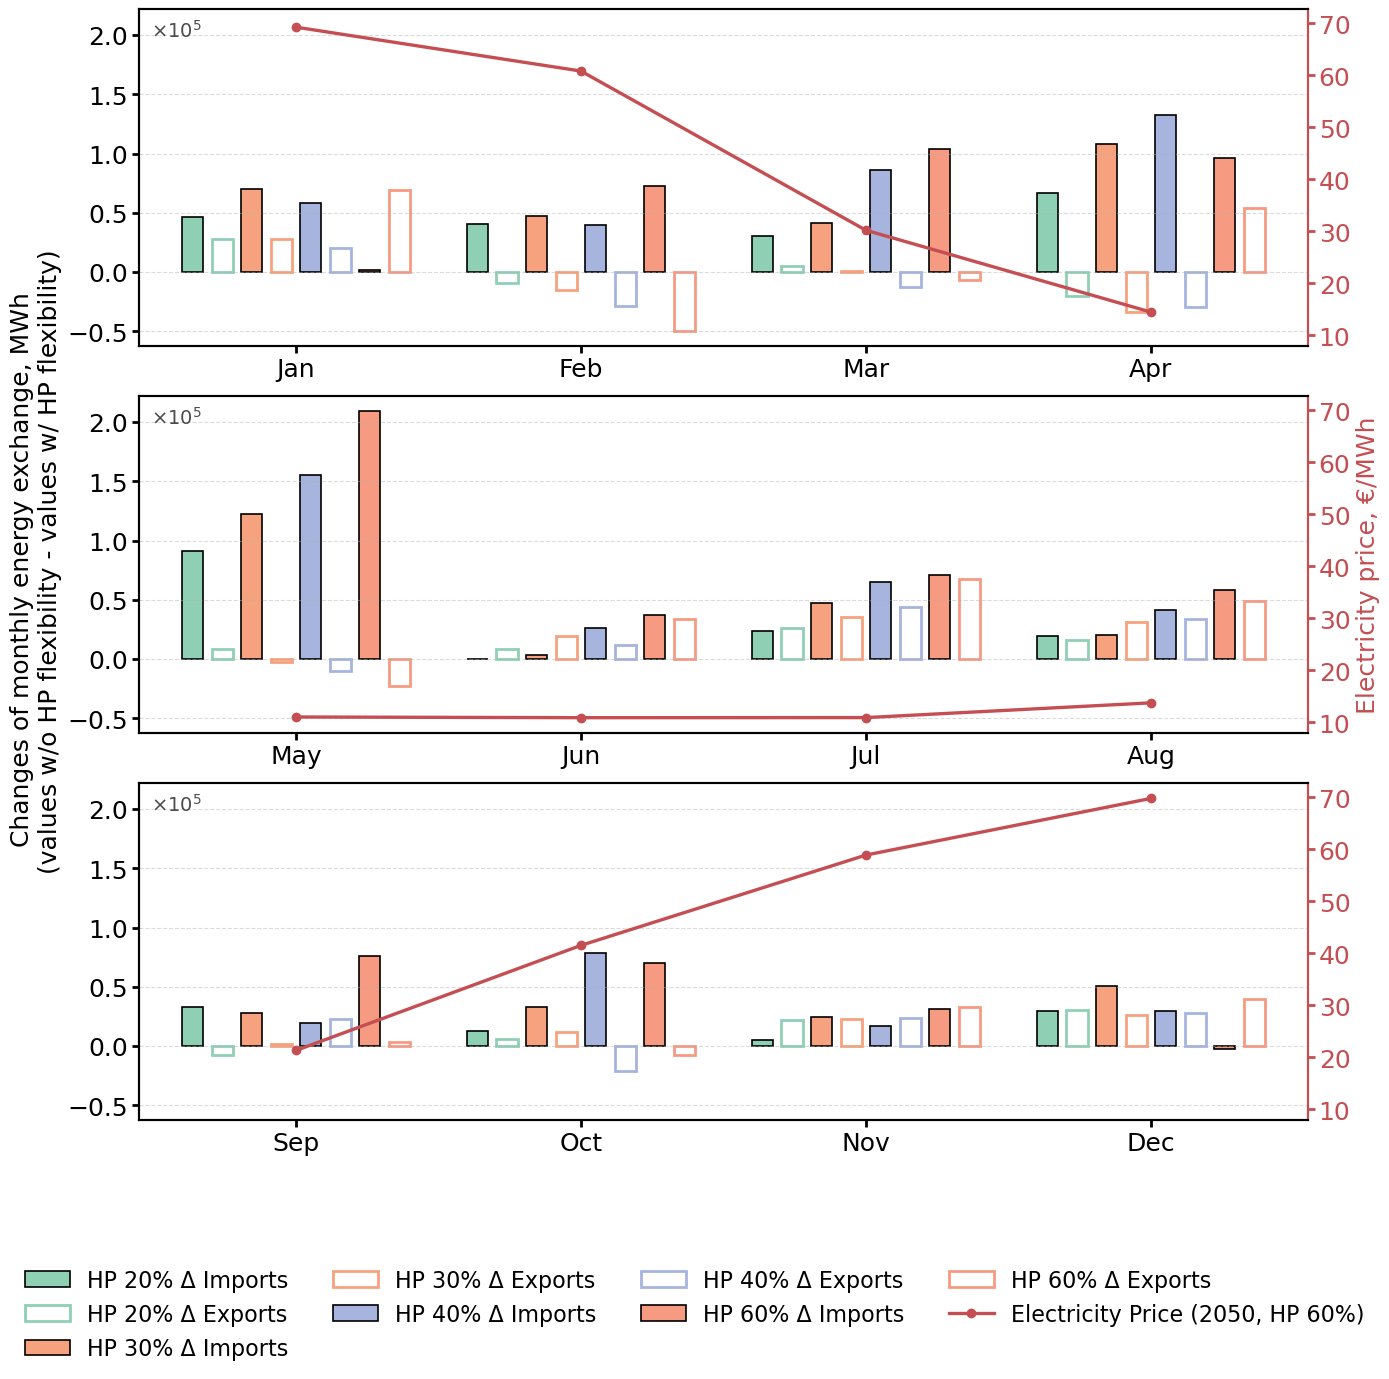

In [1]:
# ================================================================================
# This cell analyses and visualizes the results as shown in Supplementary Figure 5
# ================================================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib as mpl
from pathlib import Path

# ========== Manually adjustable parameters =========
monthly_fill_fraction = 0.80   # Total fraction of each month occupied by all bars and gaps (0-1); larger values produce wider bars
inner_gap_factor      = 0.40   # Gap between scenario groups = this value × bar width
io_gap_factor         = 0.40   # Gap between ΔImp and ΔExp within the same scenario = this value × bar width
max_month_fill        = 0.92   # Safety cap (automatically compressed to avoid overlap across months)
report_layout         = False  # Print layout parameters

# —— Left-axis scaling (values are displayed after division by y_scale)—— #
y_scale = 1e5                 # <<< Scaling factor
scale_tag = r'$\times 10^5$'  # Annotation text shown at the upper-left corner of the subplot

# ========== Style helper function =========
tick_font_size = 18
def apply_axis_style(ax, axis_color='black', tick_dir='out'):
    for spine in ['bottom', 'top', 'left', 'right']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1.5)
    if axis_color != 'black':
        ax.spines['right'].set_color(axis_color)
        ax.yaxis.label.set_color(axis_color)
    ax.tick_params(axis='x', which='major',
                   pad=3, width=2, length=5,
                   direction=tick_dir, color='black',
                   labelsize=tick_font_size, labelcolor='black')
    ax.tick_params(axis='y', which='major',
                   pad=3, width=2, length=5,
                   direction=tick_dir, color=axis_color,
                   labelsize=tick_font_size, labelcolor=axis_color)
    ax.xaxis.label.set_color('black')

# ========== Base path and scenario mapping =========
root = Path(r"..\Output_data\power systems results")
case_no_flex = {'HP 20%':'case1a0','HP 30%':'case1b0','HP 40%':'case1c0','HP 60%':'case1d0'}
case_flex    = {'HP 20%':'case1a',  'HP 30%':'case1b',  'HP 40%':'case1c',  'HP 60%':'case1d' }
order = ['HP 20%','HP 30%','HP 40%','HP 60%']

# Scenario colors
palette = {
    'HP 20%': '#8fd0b5',  # green
    'HP 30%': '#f7a27e',  # orange
    'HP 40%': '#a6b4de',  # blue
    'HP 60%': '#f79a82',  # coral
}

price_line_color = '#C44E52'
price_marker = 'o'

# ========== I/O =========
def load_hourly_skip_first(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=1, header=None, names=['Hour','Value'], usecols=[0,1])
    df['Hour']  = pd.to_numeric(df['Hour'], errors='coerce')
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    df = df.dropna(subset=['Hour','Value']).reset_index(drop=True)
    df['Hour'] = df['Hour'].astype(int)
    return df

def month_index_from_hour(hour_series: pd.Series, year="2050") -> pd.Series:
    dr = pd.date_range(start=f'{year}-01-01 00:00:00', periods=8760, freq='H')
    mapping = pd.Series(dr.month, index=range(0,8760))
    return hour_series.map(mapping)

def load_monthly_exports_imports(case_name: str):
    base = root / case_name / "CentIv_2050"
    df_e = load_hourly_skip_first(base/"0-CH_exports.csv")
    df_i = load_hourly_skip_first(base/"0-CH_imports.csv")
    df_e['Month'] = month_index_from_hour(df_e['Hour'])
    df_i['Month'] = month_index_from_hour(df_i['Hour'])
    exp = df_e.groupby('Month')['Value'].sum().reindex(range(1,13)).values
    imp = df_i.groupby('Month')['Value'].sum().reindex(range(1,13)).values
    return exp, imp

def load_monthly_price(case_name: str):
    pfile = root / case_name / "national_generation_and_capacity" / "0-national_elecprice_monthly_c_2050.csv"
    df = pd.read_csv(pfile, usecols=['Month','Switzerland']).rename(columns={'Switzerland':'Price'})
    df['Month'] = pd.to_numeric(df['Month'], errors='coerce').astype('Int64')
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
    df = df.dropna().astype({'Month':'int'}).sort_values('Month')
    return df.set_index('Month').reindex(range(1,13))['Price'].values

# ========== Data (Δ = no-flex − flex) =========
rel = {}
for lbl in order:
    exp0, imp0 = load_monthly_exports_imports(case_no_flex[lbl])
    exp1, imp1 = load_monthly_exports_imports(case_flex[lbl])
    rel[lbl] = {'exp': exp0 - exp1, 'imp': imp0 - imp1}

price_2050 = load_monthly_price(case_no_flex['HP 60%'])

# ========== Layout (within each scenario, ΔImp is on the left and ΔExp is on the right) =========
S = 4
den_raw = S*(2 + io_gap_factor) + (S-1)*inner_gap_factor
w = monthly_fill_fraction / max(den_raw, 1e-9)
group_width_raw = S*(2 + io_gap_factor)*w + (S-1)*inner_gap_factor*w
if group_width_raw > max_month_fill:
    w *= (max_month_fill / group_width_raw)

g_inner = inner_gap_factor * w
bar_width = w
io_gap   = io_gap_factor * w

group_width = S*(2*w + io_gap) + (S-1)*g_inner
centers = np.array([ -group_width/2 + ((2*w + io_gap)/2) + s*((2*w + io_gap) + g_inner) for s in range(S) ])
offset_imp = - (w/2 + io_gap/2)   # Left: ΔImports
offset_exp = + (w/2 + io_gap/2)   # Right: ΔExports

# ========== Other plotting parameters =========
months_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
blocks = [(1,4),(5,8),(9,12)]
plt.rcParams.update({'axes.titlesize':20,'axes.labelsize':18,'legend.fontsize':16})
fig, axes = plt.subplots(3,1, figsize=(14,14), sharey=True)

# Y-axis limits (after scaling)
all_vals = []
for lbl in order:
    all_vals.extend((rel[lbl]['exp']/y_scale))
    all_vals.extend((rel[lbl]['imp']/y_scale))
all_vals = np.array(all_vals)
ymin, ymax = all_vals.min(), all_vals.max()
ypad = 0.05 * (ymax - ymin if ymax != ymin else 1.0)
pmin, pmax = price_2050.min(), price_2050.max()
ppad = 0.05 * (pmax - pmin if pmax != pmin else 1.0)

# ========== Plotting =========
for ax_idx, (m1, m2) in enumerate(blocks):
    ax1 = axes[ax_idx]
    months = np.arange(m1, m2+1)

    for si, lbl in enumerate(order):
        col = palette[lbl]
        xc = months + centers[si]
        imp_seg = rel[lbl]['imp'][m1-1:m2] / y_scale
        exp_seg = rel[lbl]['exp'][m1-1:m2] / y_scale

        # ΔImports: filled bars with black edges (left)
        ax1.bar(xc + offset_imp, imp_seg, width=bar_width,
                color=col, edgecolor='black', linewidth=1.2)
        # ΔExports: hollow bars with colored edges (right)
        ax1.bar(xc + offset_exp, exp_seg, width=bar_width,
                facecolor='none', edgecolor=col, linewidth=2.0)

    # Left axis
    ax1.set_xlim(m1-0.55, m2+0.55)
    ax1.set_ylim(ymin-ypad, ymax+ypad)
    ax1.set_xticks(months)
    ax1.set_xticklabels(months_labels[m1-1:m2])
    ax1.grid(axis='y', linestyle='--', alpha=0.45)
    apply_axis_style(ax1, axis_color='black', tick_dir='out')

    # Use only the y-axis title text without ×10^5
    if ax_idx == 1:
        ax1.set_ylabel('Changes of monthly energy exchange, MWh \n (values w/o HP flexibility - values w/ HP flexibility)')

    # Add a ×10^5 annotation at the upper-left corner of each subplot #
    # Use axis coordinates in the transform; (0.01, 0.97) places the text further toward the upper-left corner and can be fine-tuned
    ax1.text(0.01, 0.97, scale_tag, transform=ax1.transAxes,
             ha='left', va='top', fontsize=14, color='black', alpha=0.7)

    # Right axis: electricity price (every 10 €/MWh)
    ax2 = ax1.twinx()
    seg = price_2050[m1-1:m2]
    ax2.plot(months, seg, color=price_line_color, marker=price_marker, linewidth=2.4,
             label="Electricity Price (2050, HP 60%)" if ax_idx==0 else "")
    ax2.set_ylim(pmin-ppad, pmax+ppad)
    ax2.yaxis.set_major_locator(MultipleLocator(10))
    apply_axis_style(ax2, axis_color=price_line_color, tick_dir='out')
    if ax_idx == 1:
        ax2.set_ylabel('Electricity price, €/MWh')

# ========== Legend (scenario-by-scenario, two bar types, plus electricity price) =========
legend_handles = []
for lbl in order:
    col = palette[lbl]
    legend_handles.append(Patch(facecolor=col, edgecolor='black', linewidth=1.2, label=f'{lbl} Δ Imports'))
    legend_handles.append(Patch(facecolor='none', edgecolor=col, linewidth=2.0, label=f'{lbl} Δ Exports'))

legend_handles.append(Line2D([0],[0], color=price_line_color, marker='o',
                             linewidth=2.4, label='Electricity Price (2050, HP 60%)'))

fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout(rect=[0, 0.12, 1, 0.96])
# ========== Additional step: export as SVG (text remains editable and is not converted to outlines) =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Do not use LaTeX rendering to avoid converting text to outlines
mpl.rcParams['font.family'] = ['Arial']

# # Export path (modify as needed)
# out_path = Path.cwd() / "figure_for_AI.svg"

# # Save as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ========== plt.show()

